<a href="https://colab.research.google.com/github/namirachmi08/Pre-Processing-Data/blob/main/Kelompok_Pemteks_Text_Pre_pocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kelas 2025C

Nama Anggota Kelompok:

Namira Rachmi Andini (Nim 25031554153)

Syahira Nanda Raihanna (Nim 25031554199)

# Chapter 4 - Text Pre-processing Data Books to Scrape

In [ ]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

import pandas as pd
import re
import string
import nltk
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
base_url = "https://books.toscrape.com/"

data = []

for page in range(1, 51):
    if page == 1:
        url = base_url
    else:
        url = f"{base_url}catalogue/page-{page}.html"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    books = soup.find_all("article", class_="product_pod")

    for book in books:
        title = book.h3.a.get("title", "")

        # Link menuju halaman detail buku
        detail_url = urljoin(url, book.h3.a.get("href", ""))

        # Mengambil halaman detail buku
        detail_response = requests.get(detail_url)
        detail_soup = BeautifulSoup(detail_response.text, "html.parser")

        # Mengambil deskripsi
        description = ""
        description_tag = detail_soup.find("div", id="product_description")

        if description_tag:
            description_p = description_tag.find_next_sibling("p")

            if description_p:
                description = description_p.get_text(" ", strip=True)

        data.append([title, description])

df = pd.DataFrame(data, columns=["Title", "Description"])
print("Jumlah data:", len(df))

Jumlah data: 1000


## Membuat Data Teks

Judul dan deskripsi digabungkan menjadi satu kolom teks untuk proses text preprocessing.

In [ ]:
df["Text"] = df["Title"].fillna("") + " " + df["Description"].fillna("")

df.head()

,Title,Description,Text
0,A Light in the Attic,It's hard to imagine a world without A Light i...,A Light in the Attic It's hard to imagine a wo...
1,Tipping the Velvet,"""Erotic and absorbing...Written with starling ...","Tipping the Velvet ""Erotic and absorbing...Wri..."
2,Soumission,"Dans une France assez proche de la nÃ´tre, un ...",Soumission Dans une France assez proche de la ...
3,Sharp Objects,"WICKED above her hipbone, GIRL across her hear...","Sharp Objects WICKED above her hipbone, GIRL a..."
4,Sapiens: A Brief History of Humankind,From a renowned historian comes a groundbreaki...,Sapiens: A Brief History of Humankind From a r...


In [ ]:
display(df.head(100))

,Title,Description,Text
0,A Light in the Attic,It's hard to imagine a world without A Light i...,A Light in the Attic It's hard to imagine a wo...
1,Tipping the Velvet,"""Erotic and absorbing...Written with starling ...","Tipping the Velvet ""Erotic and absorbing...Wri..."
2,Soumission,"Dans une France assez proche de la nÃ´tre, un ...",Soumission Dans une France assez proche de la ...
3,Sharp Objects,"WICKED above her hipbone, GIRL across her hear...","Sharp Objects WICKED above her hipbone, GIRL a..."
4,Sapiens: A Brief History of Humankind,From a renowned historian comes a groundbreaki...,Sapiens: A Brief History of Humankind From a r...
...,...,...,...
95,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...,This New York Times Bestselling series continu...,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...
96,"Layered: Baking, Building, and Styling Spectac...",Itâs time to venture beyond vanilla and choc...,"Layered: Baking, Building, and Styling Spectac..."
97,Judo: Seven Steps to Black Belt (an Introducto...,"Displaying the most impressive throws, compell...",Judo: Seven Steps to Black Belt (an Introducto...
98,Join,What if you could live multiple lives simultan...,Join What if you could live multiple lives sim...


## WordCloud Sebelum Text Pre-processing

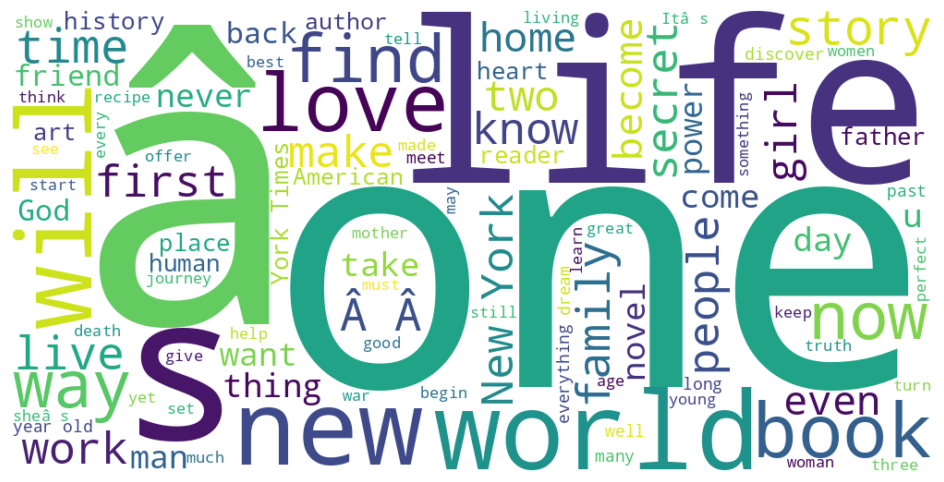

In [ ]:
text_raw = " ".join(df["Text"].dropna().astype(str))

wordcloud = WordCloud(width=1000, height=500, background_color="white", max_words=100).generate(text_raw)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## 1. Remove HTML Tags

Menghapus tag HTML yang masih terdapat pada teks jika ada.

In [ ]:
def remove_html(text):
    return re.sub(r'<.*?>', '', text)

df["Text_Clean"] = df["Text"].apply(remove_html)

df[["Text", "Text_Clean"]].head(100)

,Text,Text_Clean
0,A Light in the Attic It's hard to imagine a wo...,A Light in the Attic It's hard to imagine a wo...
1,"Tipping the Velvet ""Erotic and absorbing...Wri...","Tipping the Velvet ""Erotic and absorbing...Wri..."
2,Soumission Dans une France assez proche de la ...,Soumission Dans une France assez proche de la ...
3,"Sharp Objects WICKED above her hipbone, GIRL a...","Sharp Objects WICKED above her hipbone, GIRL a..."
4,Sapiens: A Brief History of Humankind From a r...,Sapiens: A Brief History of Humankind From a r...
...,...,...
95,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...
96,"Layered: Baking, Building, and Styling Spectac...","Layered: Baking, Building, and Styling Spectac..."
97,Judo: Seven Steps to Black Belt (an Introducto...,Judo: Seven Steps to Black Belt (an Introducto...
98,Join What if you could live multiple lives sim...,Join What if you could live multiple lives sim...


## 2. Lower Casing

Mengubah seluruh huruf menjadi huruf kecil agar kata yang sama dengan perbedaan kapitalisasi dianggap sebagai kata yang sama.

In [ ]:
df["Text_Clean"] = df["Text_Clean"].str.lower()
df[["Text", "Text_Clean"]].head(100)

,Text,Text_Clean
0,A Light in the Attic It's hard to imagine a wo...,a light in the attic it's hard to imagine a wo...
1,"Tipping the Velvet ""Erotic and absorbing...Wri...","tipping the velvet ""erotic and absorbing...wri..."
2,Soumission Dans une France assez proche de la ...,soumission dans une france assez proche de la ...
3,"Sharp Objects WICKED above her hipbone, GIRL a...","sharp objects wicked above her hipbone, girl a..."
4,Sapiens: A Brief History of Humankind From a r...,sapiens: a brief history of humankind from a r...
...,...,...
95,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...,lumberjanes vol. 3: a terrible plan (lumberjan...
96,"Layered: Baking, Building, and Styling Spectac...","layered: baking, building, and styling spectac..."
97,Judo: Seven Steps to Black Belt (an Introducto...,judo: seven steps to black belt (an introducto...
98,Join What if you could live multiple lives sim...,join what if you could live multiple lives sim...


## 3. Remove Punctuation

Menghapus tanda baca seperti titik, koma, tanda seru, tanda tanya, dan tanda baca lainnya.

In [ ]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df["Text_Clean"] = df["Text_Clean"].apply(remove_punctuation)
df[["Text", "Text_Clean"]].head(100)

,Text,Text_Clean
0,A Light in the Attic It's hard to imagine a wo...,a light in the attic its hard to imagine a wor...
1,"Tipping the Velvet ""Erotic and absorbing...Wri...",tipping the velvet erotic and absorbingwritten...
2,Soumission Dans une France assez proche de la ...,soumission dans une france assez proche de la ...
3,"Sharp Objects WICKED above her hipbone, GIRL a...",sharp objects wicked above her hipbone girl ac...
4,Sapiens: A Brief History of Humankind From a r...,sapiens a brief history of humankind from a re...
...,...,...
95,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...,lumberjanes vol 3 a terrible plan lumberjanes ...
96,"Layered: Baking, Building, and Styling Spectac...",layered baking building and styling spectacula...
97,Judo: Seven Steps to Black Belt (an Introducto...,judo seven steps to black belt an introductory...
98,Join What if you could live multiple lives sim...,join what if you could live multiple lives sim...


## 4. Remove Numbers

Menghapus angka yang terdapat dalam teks.

In [ ]:
#cara melihat batas judul yang tepat
print(df.loc[95, "Title"])

Lumberjanes Vol. 3: A Terrible Plan (Lumberjanes #9-12)


In [ ]:
# mempertahankan angka yang ada di judul
def remove_numbers(text):
    return re.sub(r'\d+', '', str(text))

df["Description_Clean"] = df["Description"].apply(remove_numbers)

df["Text_Clean"] = (
    df["Title"].astype(str) + " " +
    df["Description_Clean"].astype(str)
).str.lower()

df[["Text", "Text_Clean"]].head(100)

,Text,Text_Clean
0,A Light in the Attic It's hard to imagine a wo...,a light in the attic it's hard to imagine a wo...
1,"Tipping the Velvet ""Erotic and absorbing...Wri...","tipping the velvet ""erotic and absorbing...wri..."
2,Soumission Dans une France assez proche de la ...,soumission dans une france assez proche de la ...
3,"Sharp Objects WICKED above her hipbone, GIRL a...","sharp objects wicked above her hipbone, girl a..."
4,Sapiens: A Brief History of Humankind From a r...,sapiens: a brief history of humankind from a r...
...,...,...
95,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...,lumberjanes vol. 3: a terrible plan (lumberjan...
96,"Layered: Baking, Building, and Styling Spectac...","layered: baking, building, and styling spectac..."
97,Judo: Seven Steps to Black Belt (an Introducto...,judo: seven steps to black belt (an introducto...
98,Join What if you could live multiple lives sim...,join what if you could live multiple lives sim...


In [ ]:
# menghapus semua angka di deskripsi walaupun kalimat pertama mengandung judul
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

df["Text_Clean"] = df["Text_Clean"].apply(remove_numbers)

df[["Text", "Text_Clean"]].head(100)

,Text,Text_Clean
0,A Light in the Attic It's hard to imagine a wo...,a light in the attic it's hard to imagine a wo...
1,"Tipping the Velvet ""Erotic and absorbing...Wri...","tipping the velvet ""erotic and absorbing...wri..."
2,Soumission Dans une France assez proche de la ...,soumission dans une france assez proche de la ...
3,"Sharp Objects WICKED above her hipbone, GIRL a...","sharp objects wicked above her hipbone, girl a..."
4,Sapiens: A Brief History of Humankind From a r...,sapiens: a brief history of humankind from a r...
...,...,...
95,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...,lumberjanes vol. : a terrible plan (lumberjane...
96,"Layered: Baking, Building, and Styling Spectac...","layered: baking, building, and styling spectac..."
97,Judo: Seven Steps to Black Belt (an Introducto...,judo: seven steps to black belt (an introducto...
98,Join What if you could live multiple lives sim...,join what if you could live multiple lives sim...


## 5. Remove Extra Spaces

Menghapus spasi berlebih sehingga teks menjadi lebih rapi.

In [ ]:
def remove_extra_spaces(text):
    return re.sub(r'\s+', ' ', text).strip()

df["Text_Clean"] = df["Text_Clean"].apply(remove_extra_spaces)
df[["Text", "Text_Clean"]].head(100)

,Text,Text_Clean
0,A Light in the Attic It's hard to imagine a wo...,a light in the attic it's hard to imagine a wo...
1,"Tipping the Velvet ""Erotic and absorbing...Wri...","tipping the velvet ""erotic and absorbing...wri..."
2,Soumission Dans une France assez proche de la ...,soumission dans une france assez proche de la ...
3,"Sharp Objects WICKED above her hipbone, GIRL a...","sharp objects wicked above her hipbone, girl a..."
4,Sapiens: A Brief History of Humankind From a r...,sapiens: a brief history of humankind from a r...
...,...,...
95,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...,lumberjanes vol. : a terrible plan (lumberjane...
96,"Layered: Baking, Building, and Styling Spectac...","layered: baking, building, and styling spectac..."
97,Judo: Seven Steps to Black Belt (an Introducto...,judo: seven steps to black belt (an introducto...
98,Join What if you could live multiple lives sim...,join what if you could live multiple lives sim...


## 6. Removal of Emojis

menghapus emoji pada judul maupun deskripsi buku jika ada

In [ ]:
!pip install demoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 626.3 kB/s eta 0:00:00


In [ ]:
import demoji

# demoji.download_codes() # Download emoji codes (run once)

def remove_emoji(text):
    cleaned_text = demoji.replace(text, repl="")
    return cleaned_text

df["Text_Clean"] = df["Text_Clean"].apply(remove_emoji)

df[["Text", "Text_Clean"]].head(100)

,Text,Text_Clean
0,A Light in the Attic It's hard to imagine a wo...,a light in the attic it's hard to imagine a wo...
1,"Tipping the Velvet ""Erotic and absorbing...Wri...","tipping the velvet ""erotic and absorbing...wri..."
2,Soumission Dans une France assez proche de la ...,soumission dans une france assez proche de la ...
3,"Sharp Objects WICKED above her hipbone, GIRL a...","sharp objects wicked above her hipbone, girl a..."
4,Sapiens: A Brief History of Humankind From a r...,sapiens: a brief history of humankind from a r...
...,...,...
95,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...,lumberjanes vol. : a terrible plan (lumberjane...
96,"Layered: Baking, Building, and Styling Spectac...","layered: baking, building, and styling spectac..."
97,Judo: Seven Steps to Black Belt (an Introducto...,judo: seven steps to black belt (an introducto...
98,Join What if you could live multiple lives sim...,join what if you could live multiple lives sim...


## 7. Remove Stopwords

Menghapus kata-kata umum dalam bahasa Inggris yang kurang memberikan informasi penting terhadap isi teks.

In [ ]:
def remove_special(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)

df["Text_Clean"] = df["Text_Clean"].apply(remove_special)

In [ ]:
stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    return " ".join(word for word in text.split()
        if word not in stop_words)

df["Text_Clean"] = df["Text_Clean"].apply(remove_stopwords)
df[["Text", "Text_Clean"]].head(10)

,Text,Text_Clean
0,A Light in the Attic It's hard to imagine a wo...,light attic hard imagine world without light a...
1,"Tipping the Velvet ""Erotic and absorbing...Wri...",tipping velvet erotic absorbingwritten starlin...
2,Soumission Dans une France assez proche de la ...,soumission dans une france assez proche de la ...
3,"Sharp Objects WICKED above her hipbone, GIRL a...",sharp objects wicked hipbone girl across heart...
4,Sapiens: A Brief History of Humankind From a r...,sapiens brief history humankind renowned histo...
5,The Requiem Red Patient Twenty-nine.A monster ...,requiem red patient twentyninea monster roams ...
6,The Dirty Little Secrets of Getting Your Dream...,dirty little secrets getting dream job drawing...
7,The Coming Woman: A Novel Based on the Life of...,coming woman novel based life infamous feminis...
8,The Boys in the Boat: Nine Americans and Their...,boys boat nine americans epic quest gold berli...
9,"The Black Maria Praise for Aracelis Girmay:""[G...",black maria praise aracelis girmaygirmays ever...


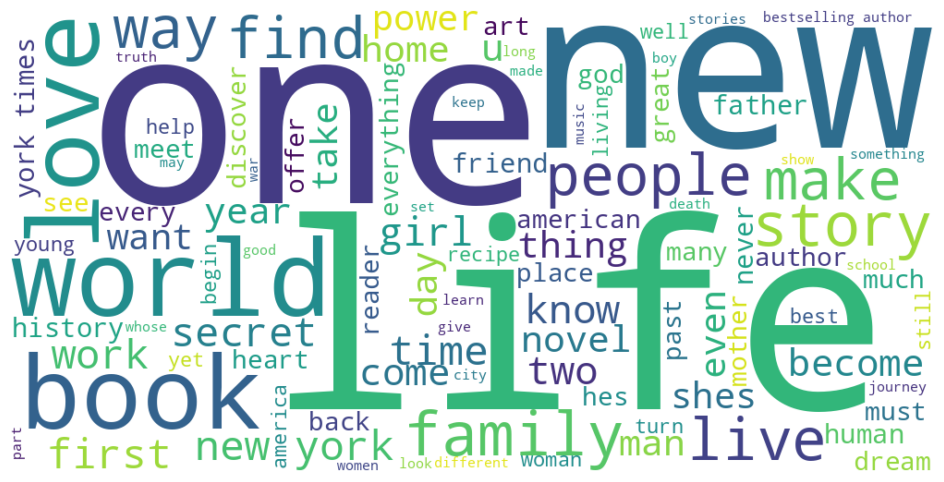

In [ ]:
text_middle = " ".join(df["Text_Clean"].dropna().astype(str))

wordcloud = WordCloud(width=1000, height=500, background_color="white", max_words=100).generate(text_middle)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
words_middle = text_middle.split()

frequent_words_2 = Counter(words_middle).most_common(20)
frequent_words_2

[('new', 954),
 ('one', 879),
 ('life', 762),
 ('world', 586),
 ('book', 536),
 ('love', 523),
 ('time', 427),
 ('story', 422),
 ('years', 393),
 ('first', 388),
 ('family', 334),
 ('like', 318),
 ('way', 303),
 ('us', 296),
 ('two', 291),
 ('author', 290),
 ('find', 289),
 ('people', 289),
 ('york', 286),
 ('young', 271)]

## 7. Stemming

Mengubah kata menjadi bentuk dasar atau bentuk stem dengan menggunakan Porter Stemmer.

In [ ]:
stemmer = PorterStemmer()

def stemming(text):
    return " ".join(stemmer.stem(word) for word in text.split())

df["Text_Clean"] = df["Text_Clean"].apply(stemming)
df[["Text", "Text_Clean"]].head(100)

,Text,Text_Clean
0,A Light in the Attic It's hard to imagine a wo...,light attic hard imagin world without light at...
1,"Tipping the Velvet ""Erotic and absorbing...Wri...",tip velvet erot absorbingwritten starl powerth...
2,Soumission Dans une France assez proche de la ...,soumiss dan une franc assez proch de la ntre u...
3,"Sharp Objects WICKED above her hipbone, GIRL a...",sharp object wick hipbon girl across heart wor...
4,Sapiens: A Brief History of Humankind From a r...,sapien brief histori humankind renown historia...
...,...,...
95,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...,lumberjan vol terribl plan lumberjan new york ...
96,"Layered: Baking, Building, and Styling Spectac...",layer bake build style spectacular cake time v...
97,Judo: Seven Steps to Black Belt (an Introducto...,judo seven step black belt introductori guid b...
98,Join What if you could live multiple lives sim...,join could live multipl live simultan constant...


## 8. Removal of Rare words

menghapus kata yang terlalu sering muncul dalam dataset karena dianggap kurang informatif.

In [ ]:
from collections import Counter

# Hitung frekuensi setiap kata
all_words = ' '.join(df["Text_Clean"]).split()
word_freq = Counter(all_words)

# Kata yang hanya muncul 1 kali
rare_words = {word for word, freq in word_freq.items() if freq == 1}

print("Jumlah rare words:", len(rare_words))

Jumlah rare words: 5942


In [ ]:
rare_words = {word for word, freq in word_freq.items() if freq <= 2}

print("Jumlah rare words:", len(rare_words))

Jumlah rare words: 9707


In [ ]:
def remove_rare_words(text):
    return " ".join(
        word for word in text.split()
        if word not in rare_words
    )

df["Text_Clean"] = df["Text_Clean"].apply(remove_rare_words)

df[["Text", "Text_Clean"]].head(10)

,Text,Text_Clean
0,A Light in the Attic It's hard to imagine a wo...,light attic hard imagin world without light at...
1,"Tipping the Velvet ""Erotic and absorbing...Wri...",tip erot new york time book review nan king oy...
2,Soumission Dans une France assez proche de la ...,dan une franc de la un dan la motiv par une vi...
3,"Sharp Objects WICKED above her hipbone, GIRL a...",sharp object wick girl across heart word like ...
4,Sapiens: A Brief History of Humankind From a r...,sapien brief histori humankind renown historia...
5,The Requiem Red Patient Twenty-nine.A monster ...,red patient monster roam hall sooth hill asylu...
6,The Dirty Little Secrets of Getting Your Dream...,dirti littl secret get dream job draw extens e...
7,The Coming Woman: A Novel Based on the Life of...,come woman novel base life infam feminist vict...
8,The Boys in the Boat: Nine Americans and Their...,boy boat nine american epic quest gold berlin ...
9,"The Black Maria Praise for Aracelis Girmay:""[G...",black maria prais arac everi call yearn connec...


## *TEKS AKHIR*

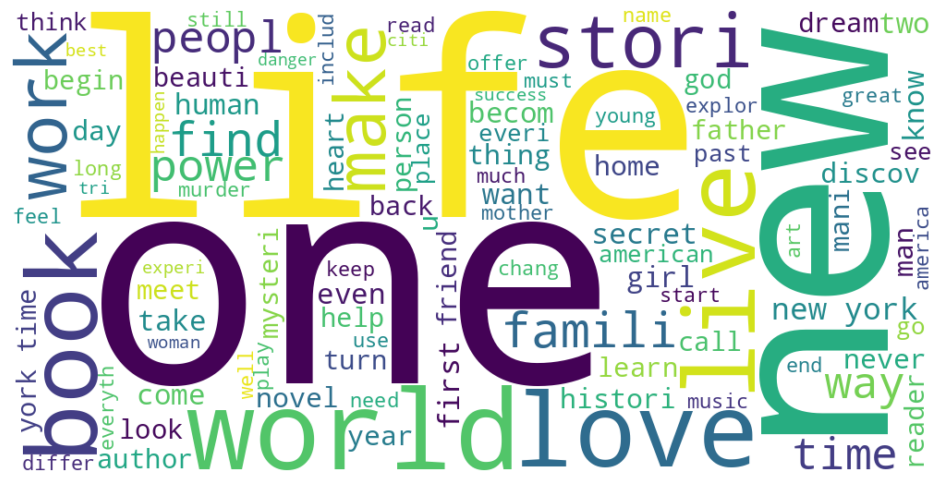

In [ ]:
text_final = " ".join(df["Text_Clean"].dropna().astype(str))

wordcloud = WordCloud(width=1000, height=500, background_color="white", max_words=100).generate(text_final)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
display(df[["Title", "Text_Clean"]].head(100))

,Title,Text_Clean
0,A Light in the Attic,light attic hard imagin world without light at...
1,Tipping the Velvet,tip erot new york time book review nan king oy...
2,Soumission,dan une franc de la un dan la motiv par une vi...
3,Sharp Objects,sharp object wick girl across heart word like ...
4,Sapiens: A Brief History of Humankind,sapien brief histori humankind renown historia...
...,...,...
95,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...,lumberjan vol terribl plan lumberjan new york ...
96,"Layered: Baking, Building, and Styling Spectac...",layer bake build style spectacular cake time v...
97,Judo: Seven Steps to Black Belt (an Introducto...,judo seven step black guid beginn display impr...
98,Join,join could live multipl live simultan constant...


In [ ]:
df[["Title", "Description", "Text", "Text_Clean"]].head(100).isnull().sum() #cek missing value

,0
Title,0
Description,0
Text,0
Text_Clean,0


In [ ]:
df.duplicated().head(100).sum() #cek data duplikat

np.int64(0)

In [ ]:
# ekspor data
df.head(100).to_excel("books_text_preprocessing.xlsx", index=False)
print("File berhasil disimpan.")

File berhasil disimpan.
